In [8]:
from IPython.core.display import HTML
import matplotlib
from matplotlib import font_manager
import shutil
sorted([font.name for font in font_manager.fontManager.ttflist])

def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

HTML("<div style='column-count: 2;'>{}</div>".format(code))

In [9]:
font_dirs = font_manager.OSXFontDirectories
font_dirs

['/Library/Fonts/',
 '/Network/Library/Fonts/',
 '/System/Library/Fonts/',
 '/opt/local/share/fonts',
 '/root/Library/Fonts']

In [10]:
for idx, f_dir in enumerate(font_dirs):
    print(f'==='*10)
    print(f'인덱스 [{idx}] \t위치: {f_dir}')
    font_list = font_manager.findSystemFonts(fontpaths=f_dir, fontext='ttf')
    print(sorted(font_list))
    print(f'==='*10)

인덱스 [0] 	위치: /Library/Fonts/
[]
인덱스 [1] 	위치: /Network/Library/Fonts/
[]
인덱스 [2] 	위치: /System/Library/Fonts/
[]
인덱스 [3] 	위치: /opt/local/share/fonts
[]
인덱스 [4] 	위치: /root/Library/Fonts
[]


In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 폰트 디렉토리 경로
font_dir = '/root/25DFT/font'

# 폰트 디렉토리의 모든 폰트 파일 찾기
font_files = []
for file in os.listdir(font_dir):
    if file.endswith(('.otf', '.ttf', '.ttc')):
        font_path = os.path.join(font_dir, file)
        font_files.append(font_path)
        print(f"Found font: {file}")

print(f"\n총 {len(font_files)}개의 폰트 파일을 찾았습니다.")


Found font: flama 2.otf
Found font: Flama-Light.otf
Found font: Flama-Regular.otf
Found font: flama.otf

총 4개의 폰트 파일을 찾았습니다.


✓ 등록 성공: Flama (flama 2.otf)
✓ 등록 성공: Flama (Flama-Light.otf)
✓ 등록 성공: Flama (Flama-Regular.otf)
✓ 등록 성공: Flama (flama.otf)

총 4개의 폰트가 등록되었습니다.


In [13]:
# 등록된 폰트 이름 확인
print("등록된 폰트 이름 목록:")
for font_name, font_path in registered_fonts:
    print(f"  - {font_name}")

# matplotlib에서 사용 가능한 폰트 목록에 포함되어 있는지 확인
all_fonts = sorted(set([f.name for f in font_manager.fontManager.ttflist]))
flama_fonts = [f for f in all_fonts if 'flama' in f.lower() or 'Flama' in f]

print(f"\nmatplotlib에서 인식된 Flama 폰트:")
for font in flama_fonts:
    print(f"  - {font}")


등록된 폰트 이름 목록:
  - Flama
  - Flama
  - Flama
  - Flama

matplotlib에서 인식된 Flama 폰트:
  - Flama


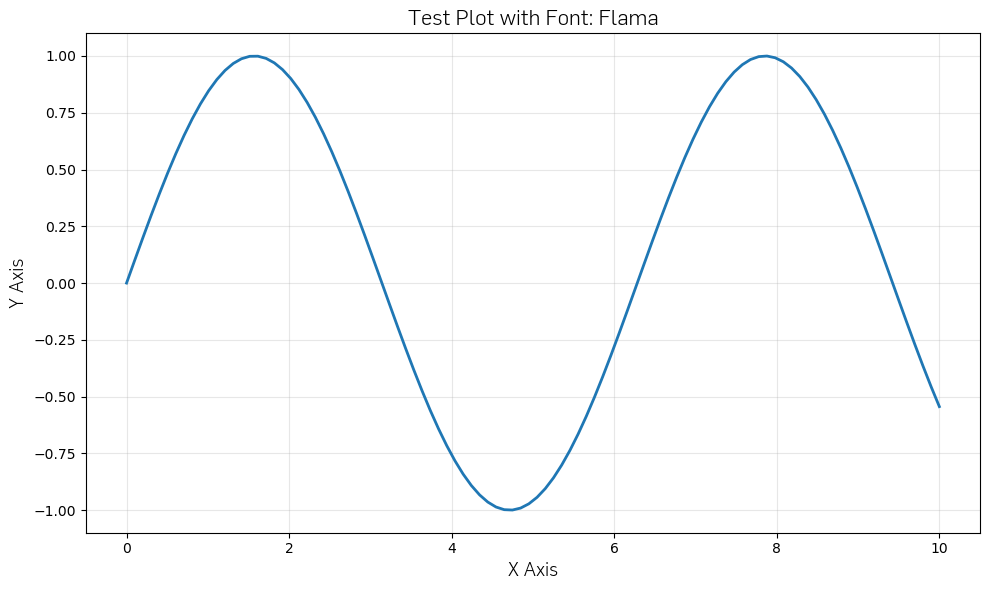

✓ 폰트 'Flama' 사용 테스트 완료!


In [14]:
# 폰트 사용 테스트 - 간단한 플롯 생성
if registered_fonts:
    # 첫 번째 등록된 폰트 사용
    test_font_name = registered_fonts[0][0]
    
    # 테스트 플롯 생성
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.linspace(0, 10, 100)
    y = np.sin(x)
    
    ax.plot(x, y, linewidth=2)
    ax.set_xlabel('X Axis', fontsize=14, fontfamily=test_font_name)
    ax.set_ylabel('Y Axis', fontsize=14, fontfamily=test_font_name)
    ax.set_title(f'Test Plot with Font: {test_font_name}', fontsize=16, fontfamily=test_font_name)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ 폰트 '{test_font_name}' 사용 테스트 완료!")
else:
    print("등록된 폰트가 없어 테스트를 수행할 수 없습니다.")


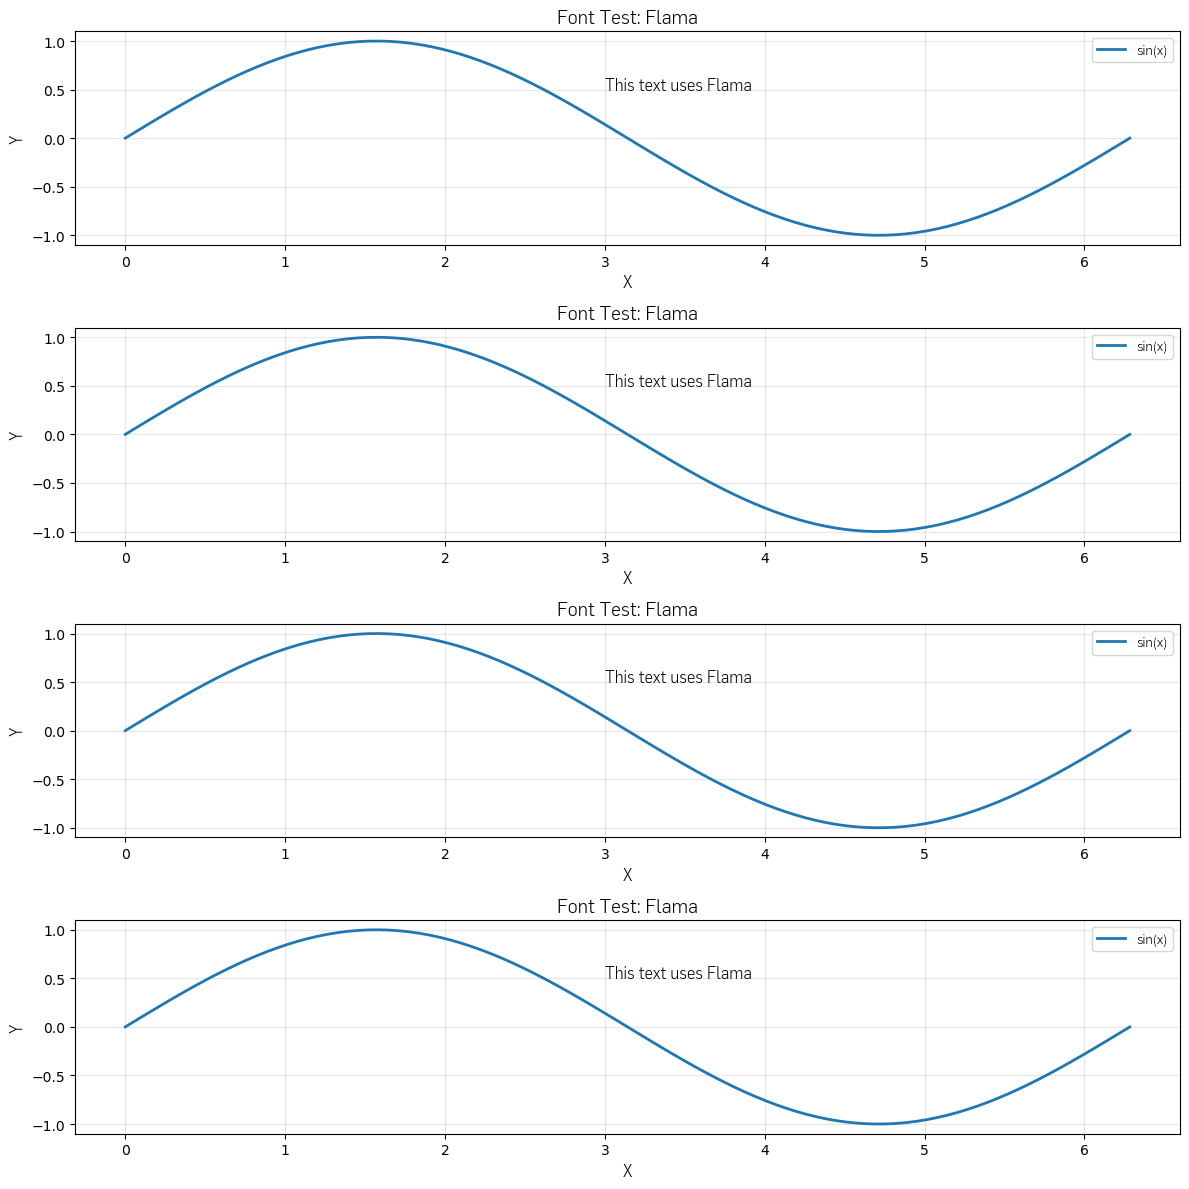

✓ 모든 폰트 테스트 완료!


In [15]:
# 모든 등록된 폰트를 한 번에 테스트
if registered_fonts:
    fig, axes = plt.subplots(len(registered_fonts), 1, figsize=(12, 3*len(registered_fonts)))
    
    if len(registered_fonts) == 1:
        axes = [axes]
    
    for idx, (font_name, font_path) in enumerate(registered_fonts):
        ax = axes[idx]
        x = np.linspace(0, 2*np.pi, 100)
        y = np.sin(x)
        
        ax.plot(x, y, linewidth=2, label='sin(x)')
        ax.set_title(f'Font Test: {font_name}', fontsize=14, fontfamily=font_name)
        ax.set_xlabel('X', fontsize=12, fontfamily=font_name)
        ax.set_ylabel('Y', fontsize=12, fontfamily=font_name)
        ax.legend(fontsize=10, prop={'family': font_name})
        ax.grid(True, alpha=0.3)
        ax.text(3, 0.5, f'This text uses {font_name}', fontsize=12, fontfamily=font_name)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ 모든 폰트 테스트 완료!")
else:
    print("등록된 폰트가 없습니다.")
